**NovaPay – Exploratory Data Analysis (EDA) Notebook**

Fraud Transaction Investigation & Pattern Discovery

This notebook performs Exploratory Data Analysis (EDA) on the cleaned nova_pay_transcations_cleaned.csv dataset.

**The goal is to understand:**

*  The behavior of genuine vs
fraudulent transactions

*  Customer patterns (location, device usage, account behavior)
* Transaction value distribution and currency effects
* Velocity, risk scores, and internal fraud signals
* Detection of data leakage or inconsistencies
* Hidden anomalies or patterns that might improve future ML models

**What this notebook will do:**

1. Load the cleaned dataset
2. Summarize distributions of major fields
3. Understand fraud vs non-fraud patterns
4. Identify correlations
5. Explore channel, country, and risk signals
6. Compare behaviour differences between fraudulent and legitimate transactions
7. Prepare insights for feature engineering and modeling

In [117]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
plt.style.use("seaborn-v0_8")


**Load Cleaned NovaPay Data**

In [118]:
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/NOVA PAY/nova_pay_transcations_cleaned.csv", parse_dates=["timestamp"])
df.head()


,transaction_id,customer_id,timestamp,home_country,source_currency,dest_currency,channel,amount_src,amount_usd,fee,exchange_rate_src_to_dest,device_id,new_device,ip_address,ip_country,location_mismatch,ip_risk_score,kyc_tier,account_age_days,device_trust_score,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,is_fraud
0,fee8542d-8ee6-4b0d-9671-c294dd08ed26,402cccc9-28de-45b3-9af7-cc5302aa1f93,2022-10-03 18:40:59.468549+00:00,us,usd,cad,atm,278.19,278.19,4.25,1.000000,9f292dcc-3297-4947-a260-6a1ef69041ff,False,221.78.171.180,us,False,0.123,standard,263,0.522,0,0.223,0,0,0.0,0
1,bfdb9fc1-27fe-4a85-b043-4d813d679259,67c2c6b3-ef0a-4777-a3f1-c84a851bb6ad,2022-10-03 20:39:38.468549+00:00,ca,cad,mxn,web,208.51,154.29,4.24,0.739965,3a95b9f5-309f-4684-a46d-e2ff2435bf78,True,120.12.20.29,ca,False,0.569,standard,947,0.475,0,0.268,0,1,0.0,0
2,fc855034-3ea5-4993-9afa-b511d93fe5e8,6d0d9b27-fa26-45f8-93b1-2df29d182d9c,2022-10-03 23:02:43.468549+00:00,us,usd,cny,mobile,160.33,160.33,2.70,1.000000,a4737752-9aac-43ed-9d8b-2ccdffc24052,False,223.96.181.93,us,False,0.437,enhanced,367,0.939,0,0.176,0,0,0.0,0
3,2cf8c08e-42ec-444d-a755-34b9a2a0a4ca,7bd5200c-5d19-44f0-9afe-8b339a05366b,2022-10-04 01:08:53.468549+00:00,us,usd,eur,mobile,59.41,59.41,2.22,1.000000,6aeb85a3-5603-4221-896c-9e6882764f1a,False,186.228.15.74,us,False,0.594,standard,147,0.551,0,0.391,0,0,0.0,0
4,d907a74d-b426-438d-97eb-dbe911aca91c,70a93d26-8e3a-4179-900c-a4a7a74d08e5,2022-10-04 09:35:03.468549+00:00,us,usd,inr,mobile,200.96,200.96,3.61,1.000000,a5b9250e-dbe0-4c5f-a6e7-5492b7349402,False,11.82.47.62,us,False,0.121,enhanced,257,0.894,0,0.257,0,0,0.0,0


In [119]:
df.shape


(11137, 26)

**1. Dataset Overview**

Basic information about data types & missing values

In [120]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11137 entries, 0 to 11136
Data columns (total 26 columns):
 #   Column                     Non-Null Count  Dtype              
---  ------                     --------------  -----              
 0   transaction_id             11137 non-null  object             
 1   customer_id                11137 non-null  object             
 2   timestamp                  11137 non-null  datetime64[ns, UTC]
 3   home_country               11137 non-null  object             
 4   source_currency            11137 non-null  object             
 5   dest_currency              11137 non-null  object             
 6   channel                    11137 non-null  object             
 7   amount_src                 11137 non-null  float64            
 8   amount_usd                 11137 non-null  float64            
 9   fee                        11137 non-null  float64            
 10  exchange_rate_src_to_dest  11137 non-null  float64            
 11  de

In [121]:
df.isna().sum().sort_values(ascending=False)


,0
transaction_id,0
customer_id,0
timestamp,0
home_country,0
source_currency,0
dest_currency,0
channel,0
amount_src,0
amount_usd,0
fee,0


In [122]:
df.describe(include="all").T


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
transaction_id,11137,11137,fdffeb16-192a-4483-9b1e-9928e23269c2,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_id,11137,1315,402cccc9-28de-45b3-9af7-cc5302aa1f93,1474,NaN,NaN,NaN,NaN,NaN,NaN,NaN
timestamp,11137,NaN,NaN,NaN,2024-05-02 17:51:10.115319040+00:00,2022-10-03 18:40:59.468549+00:00,2023-08-14 08:37:36.468549120+00:00,2024-05-07 15:36:08.468549120+00:00,2025-01-29 13:54:32.468549120+00:00,2025-12-16 00:13:41.468549+00:00,NaN
home_country,11137,4,us,7807,NaN,NaN,NaN,NaN,NaN,NaN,NaN
source_currency,11137,3,usd,7830,NaN,NaN,NaN,NaN,NaN,NaN,NaN
dest_currency,11137,9,ngn,1442,NaN,NaN,NaN,NaN,NaN,NaN,NaN
channel,11137,4,mobile,6357,NaN,NaN,NaN,NaN,NaN,NaN,NaN
amount_src,11137.0,NaN,NaN,NaN,442.702749,7.23,92.28,160.62,297.76,11942.89,1368.963538
amount_usd,11137.0,NaN,NaN,NaN,448.499595,7.23,92.53,163.55,302.85,12498.575,1391.526964
fee,11137.0,NaN,NaN,NaN,94.747394,0.321225,2.4,3.53,5.61,9999.99,928.742966


**2. UNIVARIATE ANALYSIS**

**2.1. Target Variable Analysis (is_fraud)**

Class balance is critical for fraud detection.

/tmp/ipython-input-2146260689.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="is_fraud", palette="viridis")


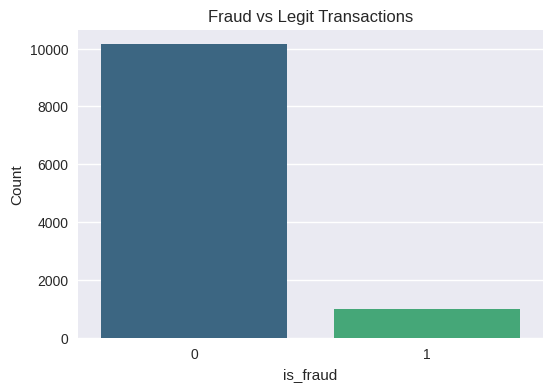

Fraud Rate: 8.92%


In [123]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="is_fraud", palette="viridis")
plt.title("Fraud vs Legit Transactions")
plt.xlabel("is_fraud")
plt.ylabel("Count")
plt.show()

fraud_rate = df["is_fraud"].mean()*100
print(f"Fraud Rate: {fraud_rate:.2f}%")


2.2 Numeric Column Distributions

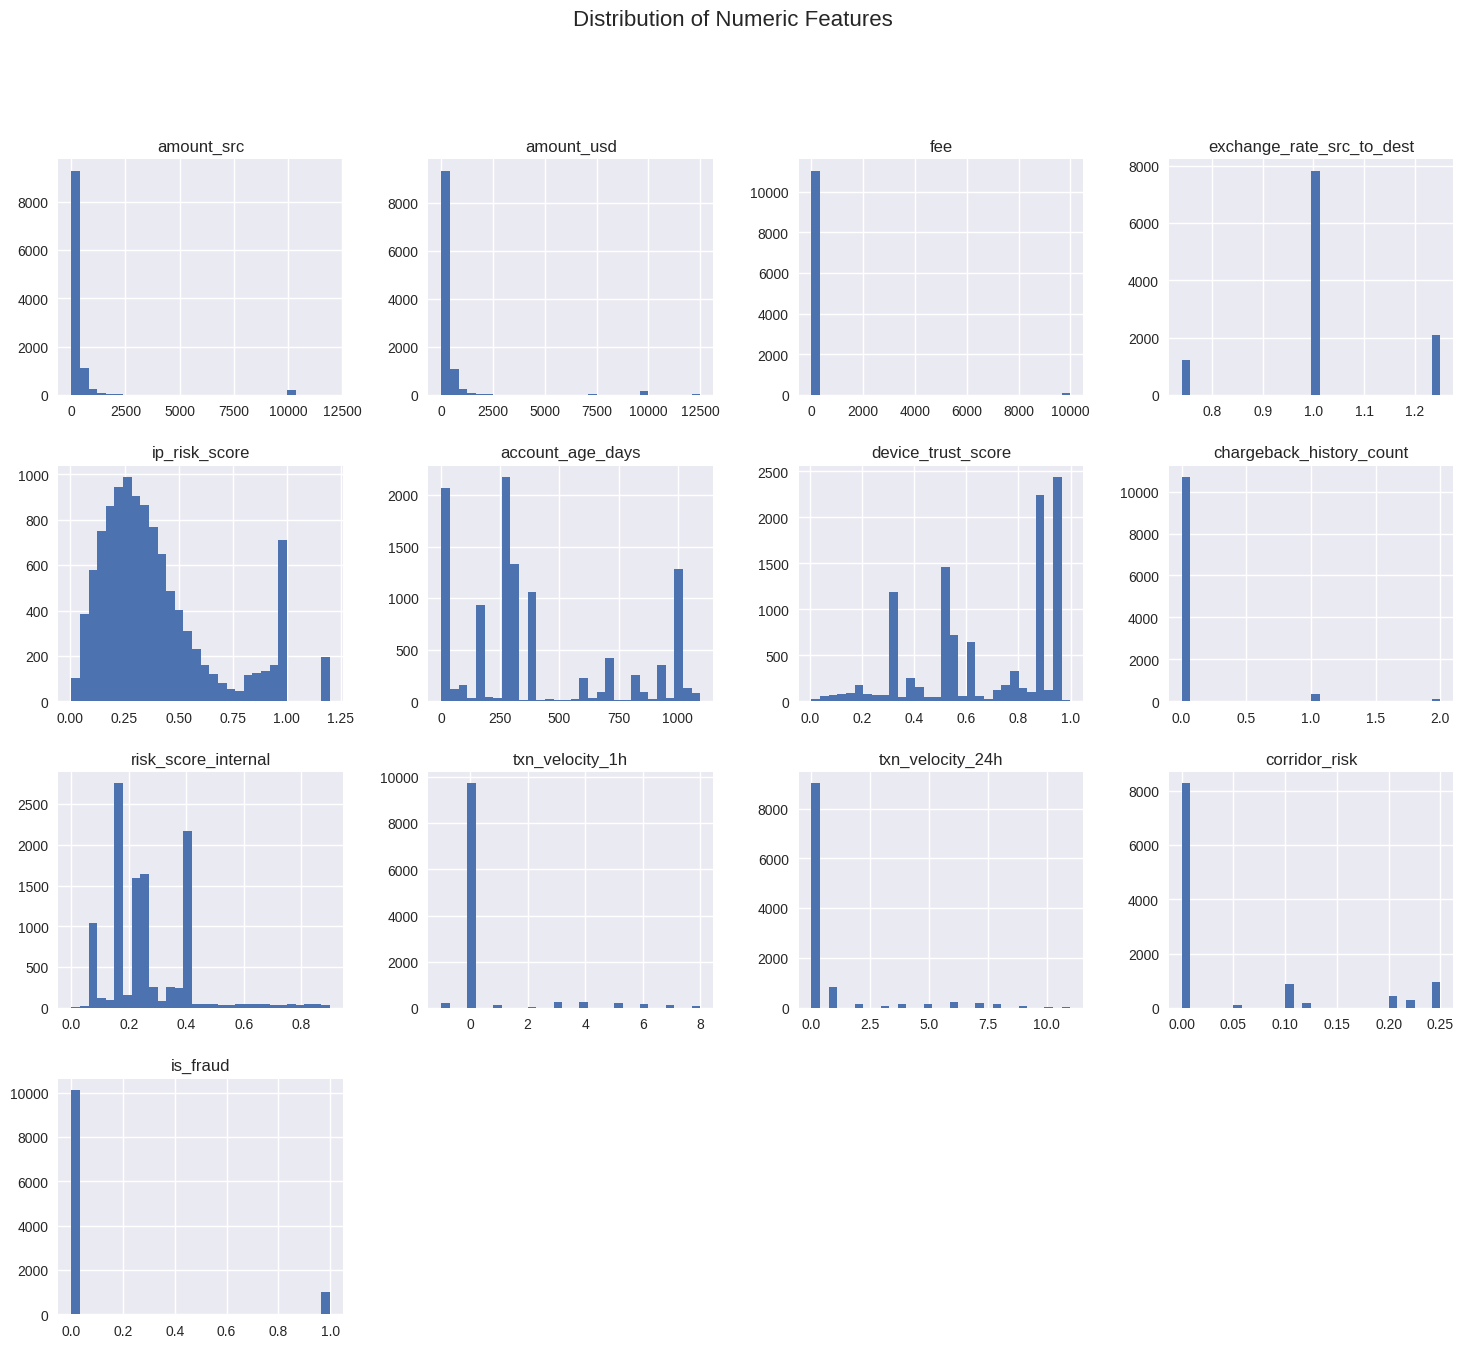

In [124]:
numeric_cols = df.select_dtypes(include=[np.number]).columns

df[numeric_cols].hist(bins=30, figsize=(18,15), color="#4C72B0")
plt.suptitle("Distribution of Numeric Features", fontsize=16)
plt.show()


2.3 Transaction Amount Distribution - Detect Outliers

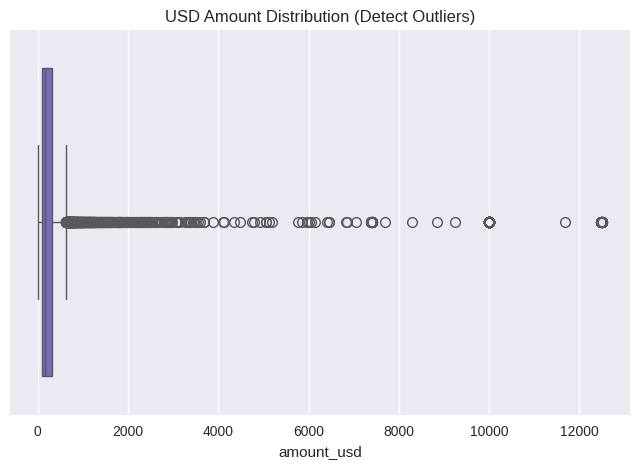

In [125]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="amount_usd", color="#6A5ACD")
plt.title("USD Amount Distribution (Detect Outliers)")
plt.show()


2.4 Channel Usage

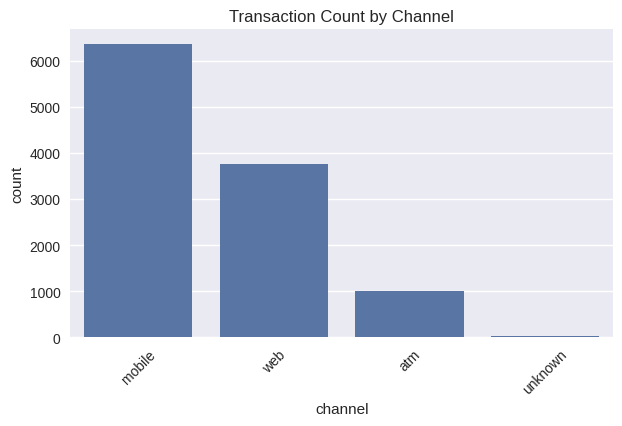

In [126]:
plt.figure(figsize=(7,4))
sns.countplot(data=df, x="channel", order=df["channel"].value_counts().index)
plt.title("Transaction Count by Channel")
plt.xticks(rotation=45)
plt.show()


2.5 KYC Tier Distribution

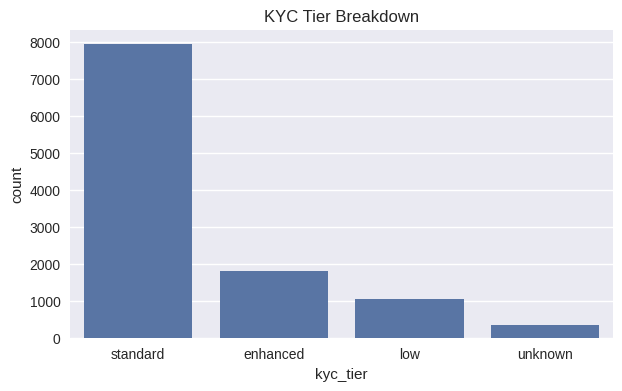

In [127]:
plt.figure(figsize=(7,4))
sns.countplot(x=df["kyc_tier"])
plt.title("KYC Tier Breakdown")
plt.show()


**3. BIVARIATE ANALYSIS**

3.1 Fraud Rate by Channel

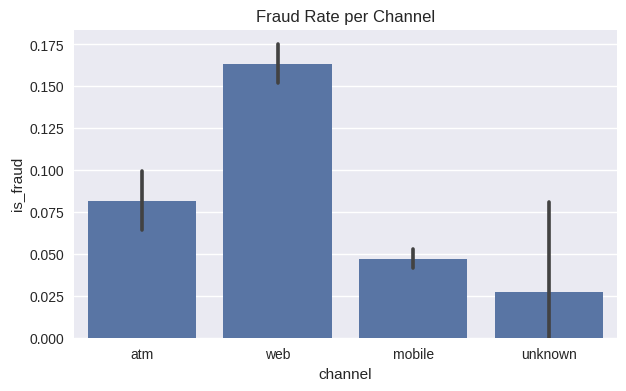

In [128]:
plt.figure(figsize=(7,4))
sns.barplot(data=df, x="channel", y="is_fraud")
plt.title("Fraud Rate per Channel")
plt.show()


3.2 Fraud Rate by KYC Tier

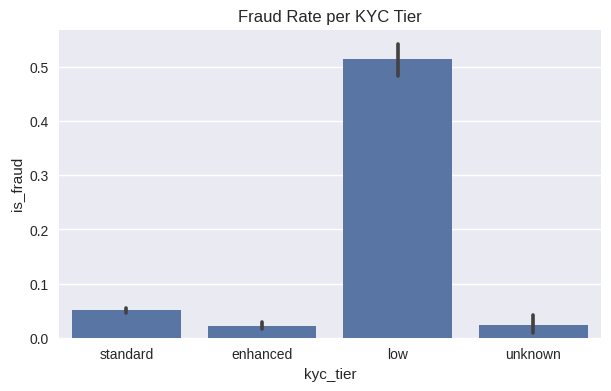

In [129]:
plt.figure(figsize=(7,4))
sns.barplot(data=df, x="kyc_tier", y="is_fraud")
plt.title("Fraud Rate per KYC Tier")
plt.show()


3.3 Relationship: Amount vs Fraud

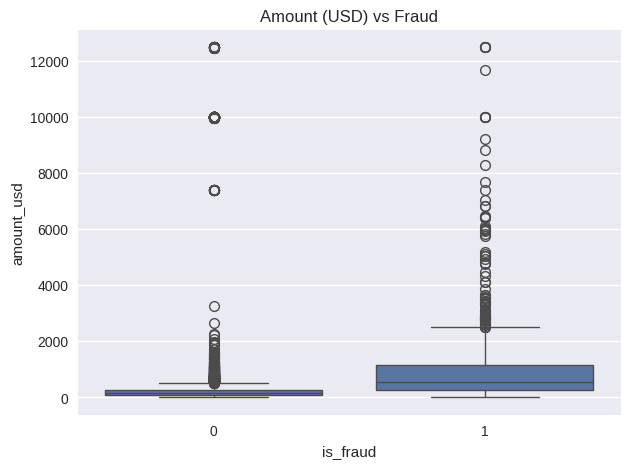

In [130]:
plt.figure(figsize=(7,5))
sns.boxplot(data=df, x="is_fraud", y="amount_usd")
plt.title("Amount (USD) vs Fraud")
plt.show()


3.4 Velocity Features vs Fraud

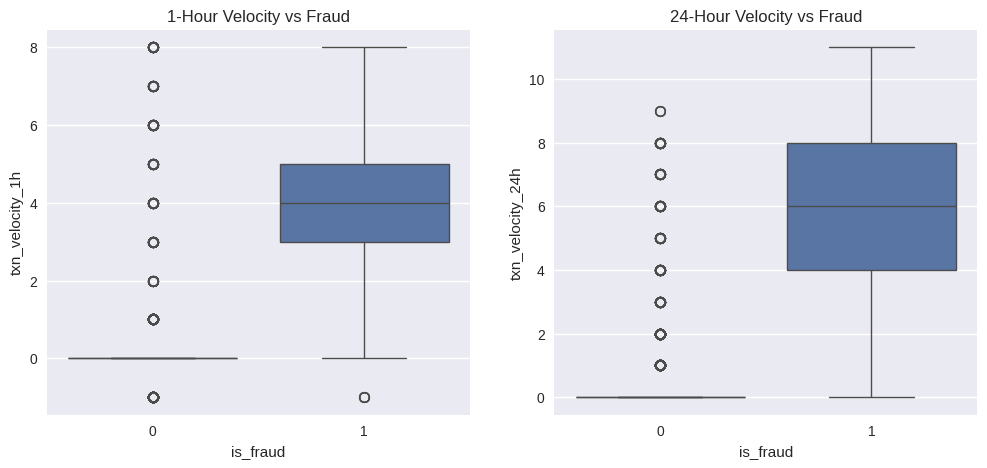

In [131]:
fig, ax = plt.subplots(1,2, figsize=(12,5))

sns.boxplot(data=df, x="is_fraud", y="txn_velocity_1h", ax=ax[0])
sns.boxplot(data=df, x="is_fraud", y="txn_velocity_24h", ax=ax[1])

ax[0].set_title("1-Hour Velocity vs Fraud")
ax[1].set_title("24-Hour Velocity vs Fraud")

plt.show()


3.5 IP Risk Score vs Fraud

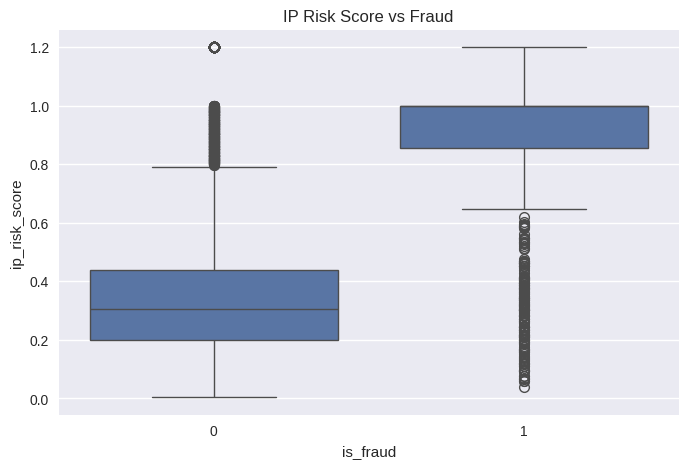

In [132]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="is_fraud", y="ip_risk_score")
plt.title("IP Risk Score vs Fraud")
plt.show()


**4. TIME-BASED ANALYSIS**

4.1 Transactions per Month

/tmp/ipython-input-4270774410.py:1: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df["month"] = df["timestamp"].dt.to_period("M")


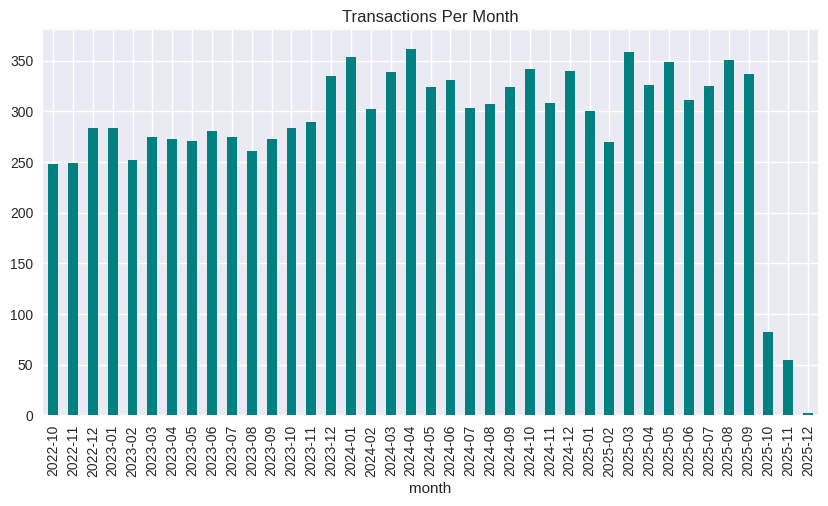

In [133]:
df["month"] = df["timestamp"].dt.to_period("M")

plt.figure(figsize=(10,5))
df["month"].value_counts().sort_index().plot(kind="bar", color="#008080")
plt.title("Transactions Per Month")
plt.show()


4.2 Fraud Trend Over Time

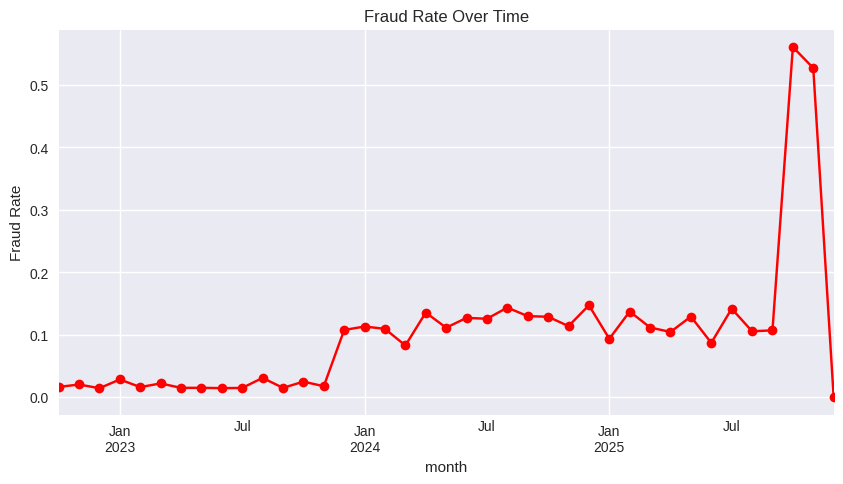

In [134]:
monthly_fraud = df.groupby("month")["is_fraud"].mean()

plt.figure(figsize=(10,5))
monthly_fraud.plot(kind="line", marker="o", color="red")
plt.title("Fraud Rate Over Time")
plt.ylabel("Fraud Rate")
plt.show()


**5. CORRELATION ANALYSIS**

5.1 Correlation Heatmap

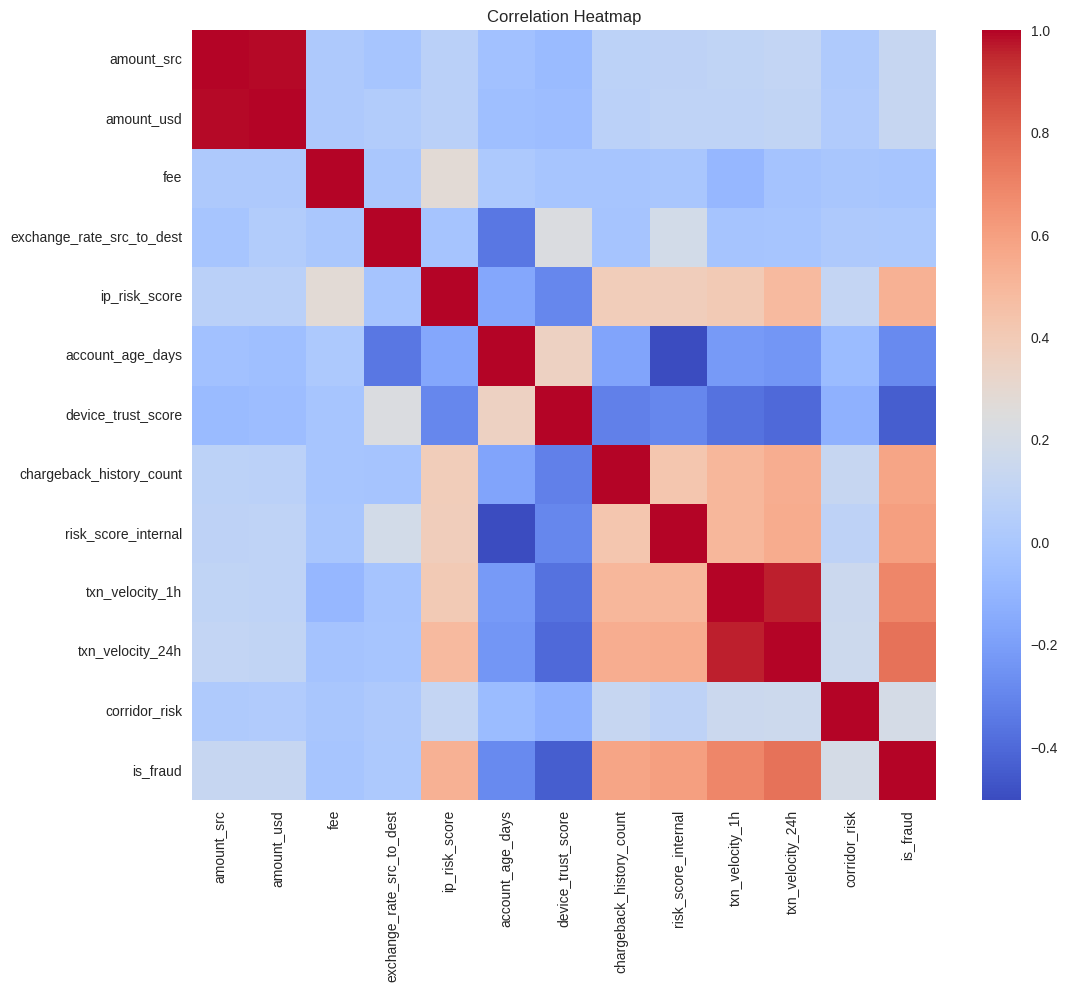

In [135]:
plt.figure(figsize=(12,10))
sns.heatmap(df[numeric_cols].corr(), cmap="coolwarm", annot=False)
plt.title("Correlation Heatmap")
plt.show()


5.2 Top Correlated Features with Fraud

In [136]:
corr = df.corr(numeric_only=True)["is_fraud"].sort_values(ascending=False)
corr.head(10)

,is_fraud
is_fraud,1.000000
txn_velocity_24h,0.753789
txn_velocity_1h,0.691090
risk_score_internal,0.604454
chargeback_history_count,0.581406
ip_risk_score,0.524430
location_mismatch,0.422087
new_device,0.381276
corridor_risk,0.195679
amount_usd,0.130047


**6. FRAUD PATTERN ANALYSIS (ADVANCED)**

6.1 Device Trust Score vs Fraud

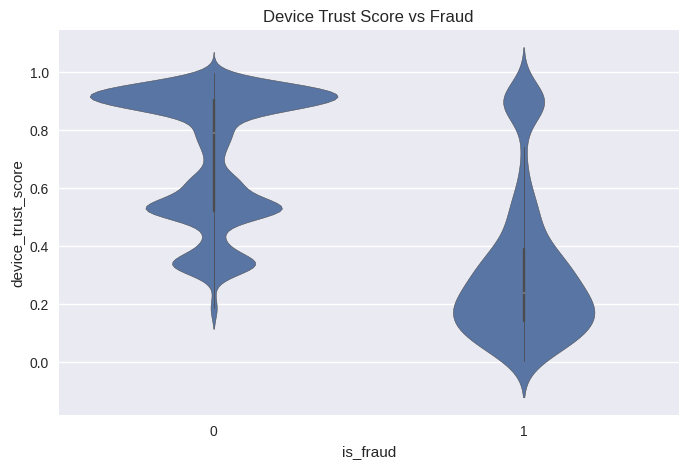

In [137]:
plt.figure(figsize=(8,5))
sns.violinplot(data=df, x="is_fraud", y="device_trust_score")
plt.title("Device Trust Score vs Fraud")
plt.show()


6.2 Account Age vs Fraud

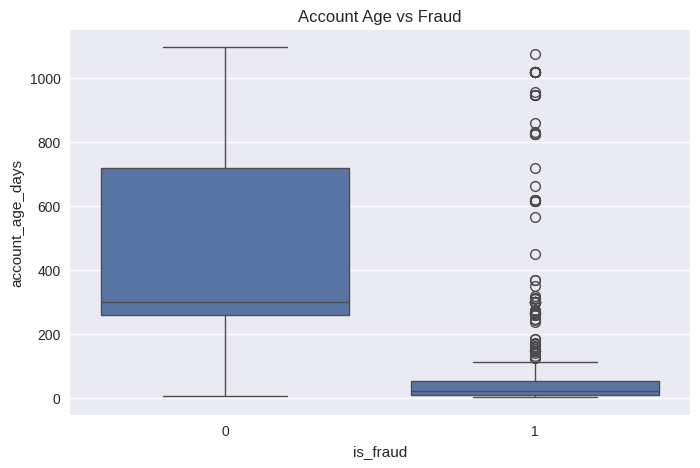

In [138]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="is_fraud", y="account_age_days")
plt.title("Account Age vs Fraud")
plt.show()


6.3 Corridor Risk vs Fraud

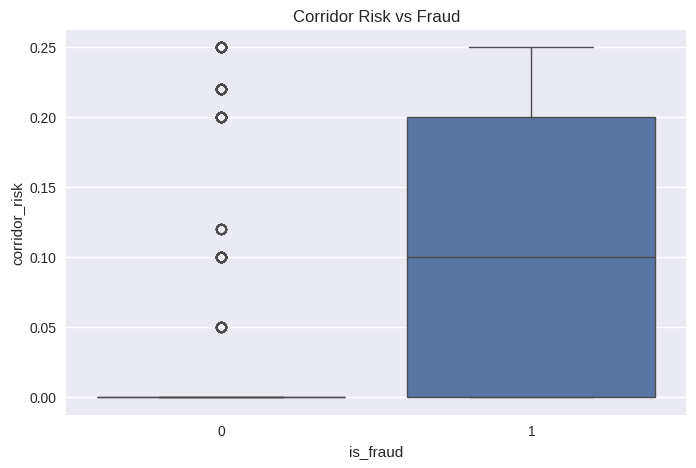

In [139]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="is_fraud", y="corridor_risk")
plt.title("Corridor Risk vs Fraud")
plt.show()


**7. KEY INSIGHTS SUMMARY**

**Fraudulent Transaction Patterns Identified**

**1. Fraudulent transactions have noticeably lower device trust scores**

Fraudulent transactions are strongly concentrated around lower device_trust_score values.
This suggests that suspicious activity often originates from:

* untrusted devices

* newly introduced devices

* devices not typically associated with the user

This feature offers a clear behavioral separation.

**2. Fraudulent transactions show higher IP risk scores**

Fraud cases appear predominantly in the upper range of ip_risk_score, while legitimate transactions span lower risk categories.
This pattern indicates:

* use of high-risk IP sources

* possible route obfuscation (VPNs, proxies)

* mismatched IP vs home country

This makes IP risk one of the most informative fraud indicators.

**3. Transaction velocity is significantly higher in fraudulent cases**

Both txn_velocity_1h and txn_velocity_24h show sharp separation between fraud and non-fraud.

Fraudulent activity is characterized by:

* many rapid transactions in a short period

* burst-style behavior

* “testing” the system with repeated attempts

Velocity features will therefore play a major predictive role.

**4. Fraud is more common among newer accounts**

The account_age_days distribution demonstrates that fraudulent accounts tend to be:

* recently created

* less established

* lacking historical activity

This aligns with behavior where fraudsters abandon accounts quickly once detected.

**5. Certain channels, especially mobile and web, carry higher fraud risk**

From the channel comparisons:

* ATM transactions show the lowest fraud level

* Mobile and Web channels display noticeably higher fraud presence

This may be linked to reduced device verification or account takeover vulnerabilities on digital channels.

**6. Fraudulent transactions appear in higher corridor risk ranges**

The corridor_risk analysis shows:

* legitimate transactions cluster around lower-risk corridors

* fraudulent ones extend into higher-risk ranges

This reinforces the value of corridor-based features.

**7. Fraudulent transactions show irregular amount patterns**

While legitimate and fraudulent amounts overlap, two clear behaviors emerged:

* a concentration of fraud around mid-to-high values

* occasional small “probing” amounts that precede larger attempts

This suggests that amount-based patterns are meaningful when combined with velocity and risk signals.




**Implications for Model Development**
**1. Velocity features will be some of the strongest predictors**

The strong separation in velocity distributions means these features will likely be among the highest contributors in machine-learning models.

**2. Combining device, IP, and account age signals gives a strong behavioral profile**

The combination of:

* low device trust

* high IP risk

* low account age

provides a clear behavioral signature of fraud in this dataset.

**3. Corridor and channel features provide important contextual strength**

Because fraud signatures vary by transaction route and channel, these features help the model:

* contextualize user behavior

* detect unusual patterns

* identify high-risk pathways

**4. Time-based features should improve performance**

Fraud activity varies across time periods, meaning features like:

* hour of day

* day of week

* transaction intervals

will help detect fraudulent patterns that exploit timing weaknesses.




**Overall Conclusion**

The EDA reveals that the dataset contains strong and meaningful fraud signals across:

* device behavior

* account characteristics

* IP and risk scoring

* velocity patterns

* channel and corridor usage

* temporal activity

These findings provide a solid foundation for building an accurate and robust fraud-detection model and guide the next steps in feature engineering and model training.

In [140]:
df.to_csv("nova_pay_with_time_features.csv", index=False)
print("Dataset with time features saved.")


Dataset with time features saved.
